The flow : Travel Problem :      ↓
Identify entities
      ↓
Identify relationships
      ↓
Design triples
      ↓
Store triples
      ↓
Build graph structure
      ↓
Add knowledge
      ↓
Query knowledge
      ↓
Traverse relationships
      ↓
Visualize the KG

# Knowledge Graph — Notebook 2
## Building a Travel Planning Knowledge Graph from Scratch

### Concept-to-Code Approach

In Notebook 1, we learned:

**Real-world information → Triples → Graph**

In this notebook, we will go one step further.

We will actually **build a small Knowledge Graph using Python**.

We will use the same running problem:

> **Travel Planning**

Our goal is to represent information about cities, destinations,
hotels, attractions, transportation, and prices as interconnected
knowledge.

We will initially use **only Python**.

No Neo4j, RDFLib, NetworkX, or other Knowledge Graph library is required.

## The Travel Planning Problem

Suppose a traveller asks:

> "I am planning a trip from Chennai.
> Which destinations can I visit?
> Which destinations are heritage places?
> Which hotels are available?
> Which hotels are affordable?
> How are different cities connected?"

To answer these questions, we need information about:

- cities
- destinations
- hotels
- attractions
- prices
- transportation
- relationships between places

The important observation is:

> **The information is not isolated. Different pieces of information are connected to one another.**

This makes Travel Planning a good problem for introducing a Knowledge Graph.

In [1]:
# Let us start with a few facts about our travel problem.

facts = [
    "Chennai is located in Tamil Nadu.",
    "Mahabalipuram is near Chennai.",
    "Mahabalipuram is a heritage destination.",
    "Hotel SeaView is located in Mahabalipuram.",
    "Hotel SeaView costs 3500 rupees per night."
]

for fact in facts:
    print(fact)

Chennai is located in Tamil Nadu.
Mahabalipuram is near Chennai.
Mahabalipuram is a heritage destination.
Hotel SeaView is located in Mahabalipuram.
Hotel SeaView costs 3500 rupees per night.


## From Natural Language to Structured Knowledge

Consider the sentence:

> "Mahabalipuram is near Chennai."

A computer program needs a structured representation of this information.

We can identify:

- **Subject** → Mahabalipuram
- **Relationship** → NEAR
- **Object** → Chennai

Therefore:

**Mahabalipuram → NEAR → Chennai**

This is called a **triple**.

In [2]:
# Represent one fact as a triple.

triple = (
    "Mahabalipuram",
    "NEAR",
    "Chennai"
)

print(triple)

('Mahabalipuram', 'NEAR', 'Chennai')


## Understanding the Triple

A triple has three components:

**Subject → Relationship → Object**

For our example:

```text
Mahabalipuram → NEAR → Chennai

In [3]:



## CELL 7 — Code


subject = triple[0]
relationship = triple[1]
object_ = triple[2]

print("Subject     :", subject)
print("Relationship:", relationship)
print("Object      :", object_)

Subject     : Mahabalipuram
Relationship: NEAR
Object      : Chennai


## Step 1: Identify the Entities

Before building the graph, let us identify the important things
in our travel domain.

For our small example, we have:

- Chennai
- Tamil Nadu
- Mahabalipuram
- Hotel SeaView
- Bengaluru
- Mysuru
- Marina Beach

These are the things about which we want to store knowledge.

We will represent these as **nodes** in our graph.

In [4]:
entities = [
    "Chennai",
    "Tamil Nadu",
    "Mahabalipuram",
    "Hotel SeaView",
    "Bengaluru",
    "Mysuru",
    "Marina Beach"
]

print("Entities:")
for entity in entities:
    print("-", entity)

Entities:
- Chennai
- Tamil Nadu
- Mahabalipuram
- Hotel SeaView
- Bengaluru
- Mysuru
- Marina Beach


## Step 2: Identify the Relationships

Now ask:

> How are these entities related?

Examples:

- Chennai is located in Tamil Nadu.
- Mahabalipuram is near Chennai.
- Mahabalipuram has the category Heritage.
- Marina Beach is located in Chennai.
- Chennai is connected to Bengaluru.
- Bengaluru is connected to Mysuru.
- Hotel SeaView is located in Mahabalipuram.

These relationships will become the **edges** of our graph.

In [5]:
relationships = [
    "LOCATED_IN",
    "NEAR",
    "HAS_CATEGORY",
    "CONNECTED_TO",
    "HAS_HOTEL",
    "HAS_ATTRACTION",
    "PRICE_PER_NIGHT"
]

print("Relationships:")
for relationship in relationships:
    print("-", relationship)

Relationships:
- LOCATED_IN
- NEAR
- HAS_CATEGORY
- CONNECTED_TO
- HAS_HOTEL
- HAS_ATTRACTION
- PRICE_PER_NIGHT


## Step 3: Design Our Travel Knowledge

We can now convert our travel information into triples.

For example:

```text
Chennai → LOCATED_IN → Tamil Nadu

Mahabalipuram → NEAR → Chennai

Mahabalipuram → HAS_CATEGORY → Heritage

Marina Beach → LOCATED_IN → Chennai

Chennai → CONNECTED_TO → Bengaluru

Bengaluru → CONNECTED_TO → Mysuru

Hotel SeaView → LOCATED_IN → Mahabalipuram

Hotel SeaView → PRICE_PER_NIGHT → 3500

In [6]:



## CELL 13 — Code


triples = [

    ("Chennai", "LOCATED_IN", "Tamil Nadu"),

    ("Mahabalipuram", "NEAR", "Chennai"),

    ("Mahabalipuram", "HAS_CATEGORY", "Heritage"),

    ("Marina Beach", "LOCATED_IN", "Chennai"),

    ("Chennai", "CONNECTED_TO", "Bengaluru"),

    ("Bengaluru", "CONNECTED_TO", "Mysuru"),

    ("Hotel SeaView", "LOCATED_IN", "Mahabalipuram"),

    ("Hotel SeaView", "PRICE_PER_NIGHT", 3500)
]

print("Number of triples:", len(triples))

Number of triples: 8


In [7]:
# Display every triple clearly.

for subject, relationship, object_ in triples:
    print(subject, "→", relationship, "→", object_)

Chennai → LOCATED_IN → Tamil Nadu
Mahabalipuram → NEAR → Chennai
Mahabalipuram → HAS_CATEGORY → Heritage
Marina Beach → LOCATED_IN → Chennai
Chennai → CONNECTED_TO → Bengaluru
Bengaluru → CONNECTED_TO → Mysuru
Hotel SeaView → LOCATED_IN → Mahabalipuram
Hotel SeaView → PRICE_PER_NIGHT → 3500


## Step 4: From Triples to a Graph

We now have a collection of triples.

Each triple gives us one connection.

For example:

```text
Mahabalipuram → NEAR → Chennai can be visualised as :
    ○ Mahabalipuram ── NEAR ──→ ○ Chennai
  similarly,   ○ Chennai ── CONNECTED_TO ──→ ○ Bengaluru

In [8]:



## CELL 16 — Code


# Create a set of all nodes appearing in our triples.

nodes = set()

for subject, relationship, object_ in triples:
    nodes.add(subject)
    nodes.add(object_)

print("Nodes in the graph:")
print()

for node in sorted(nodes, key=str):
    print("-", node)

Nodes in the graph:

- 3500
- Bengaluru
- Chennai
- Heritage
- Hotel SeaView
- Mahabalipuram
- Marina Beach
- Mysuru
- Tamil Nadu


## Important Observation: Nodes and Values

Look carefully at our nodes.

We have:

- Chennai
- Bengaluru
- Mysuru
- Mahabalipuram
- Hotel SeaView
- Tamil Nadu
- Heritage
- 3500

Are all of these the same kind of thing?

No.

For example:

**Hotel SeaView** is an entity.

**Mahabalipuram** is an entity.

But:

**3500** is a value representing a price.

This distinction becomes important when we design a formal KG schema
or use systems such as Neo4j or RDF.

## Step 5: Build the Graph Structure

A simple way to represent a graph in Python is to use a dictionary.

For each subject, we will store the relationships going out from it.

For example:

```text
Chennai
   ├── LOCATED_IN → Tamil Nadu
   └── CONNECTED_TO → Bengaluru
This is called an adjacency representation.

We are not using a graph library.

We are building the basic graph structure ourselves.

In [9]:



## CELL 19 — Code


graph = {}

for subject, relationship, object_ in triples:

    if subject not in graph:
        graph[subject] = []

    graph[subject].append(
        (relationship, object_)
    )

print("Graph structure created.")

Graph structure created.


## What Have We Built?

We have now built a very simple Knowledge Graph engine ourselves.

We have:

1. Identified entities
2. Identified relationships
3. Represented knowledge as triples
4. Stored the triples
5. Created nodes
6. Created connections between nodes
7. Represented the graph using Python

This is the basic idea behind a Knowledge Graph.

Later, specialized systems such as Neo4j can perform these tasks
more efficiently and provide powerful query and traversal mechanisms.

# Step 6: Add New Knowledge

A Knowledge Graph is not static.

As we learn new information, we can add new triples.

Suppose we discover:

- Pondicherry is near Chennai.
- Pondicherry is a heritage destination.
- Hotel Heritage is located in Pondicherry.
- Hotel Heritage costs 3000 rupees per night.

Let us add this knowledge to our graph.

In [10]:
new_triples = [

    ("Pondicherry", "NEAR", "Chennai"),

    ("Pondicherry", "HAS_CATEGORY", "Heritage"),

    ("Hotel Heritage", "LOCATED_IN", "Pondicherry"),

    ("Hotel Heritage", "PRICE_PER_NIGHT", 3000)
]

triples.extend(new_triples)

print("Total number of triples:", len(triples))

Total number of triples: 12


In [11]:
# Rebuild the graph after adding new knowledge.

graph = {}

for subject, relationship, object_ in triples:

    if subject not in graph:
        graph[subject] = []

    graph[subject].append(
        (relationship, object_)
    )

for subject, connections in graph.items():

    print("\n", subject)

    for relationship, object_ in connections:
        print("   └──", relationship, "→", object_)


 Chennai
   └── LOCATED_IN → Tamil Nadu
   └── CONNECTED_TO → Bengaluru

 Mahabalipuram
   └── NEAR → Chennai
   └── HAS_CATEGORY → Heritage

 Marina Beach
   └── LOCATED_IN → Chennai

 Bengaluru
   └── CONNECTED_TO → Mysuru

 Hotel SeaView
   └── LOCATED_IN → Mahabalipuram
   └── PRICE_PER_NIGHT → 3500

 Pondicherry
   └── NEAR → Chennai
   └── HAS_CATEGORY → Heritage

 Hotel Heritage
   └── LOCATED_IN → Pondicherry
   └── PRICE_PER_NIGHT → 3000


# Step 7: Query the Knowledge Graph

Now that we have built our graph, we can ask questions.

Consider:

> **"Which places are near Chennai?"**

We are looking for triples matching this pattern:

```text
? → NEAR → Chennai

In [12]:


## CELL 26 — Code


# Find places that are near Chennai.

places_near_chennai = []

for subject, relationship, object_ in triples:

    if relationship == "NEAR" and object_ == "Chennai":
        places_near_chennai.append(subject)

print("Places near Chennai:")

for place in places_near_chennai:
    print("-", place)

Places near Chennai:
- Mahabalipuram
- Pondicherry


# Step 8: Multi-Hop Traversal

Now consider a more interesting question:

> **"How can I travel from Chennai towards Mysuru?"**

Our graph contains:

```text
Chennai
   │
   │ CONNECTED_TO
   ↓
Bengaluru
   │
   │ CONNECTED_TO
   ↓
Mysuru

To discover this route, we need to follow more than one relationship.

This is called multi-hop traversal.

A hop means following one relationship.

1 hop → one relationship
2 hops → two relationships
3 hops → three relationships

In [13]:



## CELL 28 — Code


# Find cities directly connected to Chennai.

next_cities = []

for relationship, object_ in graph.get("Chennai", []):

    if relationship == "CONNECTED_TO":
        next_cities.append(object_)

print("Cities directly connected to Chennai:")

for city in next_cities:
    print("-", city)

Cities directly connected to Chennai:
- Bengaluru


In [14]:
# Continue the traversal from the city we found.

for city in next_cities:

    for relationship, object_ in graph.get(city, []):

        if relationship == "CONNECTED_TO":

            print(
                "Chennai →",
                city,
                "→",
                object_
            )

Chennai → Bengaluru → Mysuru


## What Did We Just Do?

We followed a path:

```text
Chennai
   ↓
Bengaluru
   ↓
Mysuru
The important point is that the answer was not stored as one sentence.

Instead, we discovered the answer by following relationships in the graph.

This is one of the major strengths of Knowledge Graphs:

Relationships are first-class citizens of the representation.


---




# Step 9: Travel Recommendation

Now let us combine several pieces of knowledge.

Suppose our traveller wants:

> **A heritage destination near Chennai with a hotel costing less than ₹4000 per night.**

This requires multiple pieces of knowledge:

```text
Destination
     ↓
NEAR
     ↓
Chennai

Destination
     ↓
HAS_CATEGORY
     ↓
Heritage

Hotel
     ↓
LOCATED_IN
     ↓
Destination

Hotel
     ↓
PRICE_PER_NIGHT
     ↓
< ₹4000
This is no longer a simple one-fact lookup.

We must combine information from several relationships.

In [15]:





# Find heritage destinations near Chennai.

near_chennai = set()
heritage_places = set()

for subject, relationship, object_ in triples:

    if relationship == "NEAR" and object_ == "Chennai":
        near_chennai.add(subject)

    if relationship == "HAS_CATEGORY" and object_ == "Heritage":
        heritage_places.add(subject)

candidate_destinations = near_chennai & heritage_places

print("Candidate heritage destinations near Chennai:")

for destination in sorted(candidate_destinations):
    print("-", destination)

Candidate heritage destinations near Chennai:
- Mahabalipuram
- Pondicherry


In [16]:
# Find hotels located in the candidate destinations.

candidate_hotels = []

for subject, relationship, object_ in triples:

    if relationship == "LOCATED_IN" and object_ in candidate_destinations:
        candidate_hotels.append(subject)

print("Hotels in candidate destinations:")

for hotel in candidate_hotels:
    print("-", hotel)

Hotels in candidate destinations:
- Hotel SeaView
- Hotel Heritage


In [17]:
# Find the prices of the candidate hotels.

hotel_prices = {}

for subject, relationship, object_ in triples:

    if (
        relationship == "PRICE_PER_NIGHT"
        and subject in candidate_hotels
    ):
        hotel_prices[subject] = object_

print("Hotel prices:")

for hotel, price in hotel_prices.items():
    print(hotel, ":", price)

Hotel prices:
Hotel SeaView : 3500
Hotel Heritage : 3000


In [18]:
# Apply the traveler's budget.

budget = 4000

affordable_hotels = {}

for hotel, price in hotel_prices.items():

    if price < budget:
        affordable_hotels[hotel] = price

print("Affordable hotels:")

for hotel, price in affordable_hotels.items():
    print("-", hotel, ":", price)

Affordable hotels:
- Hotel SeaView : 3500
- Hotel Heritage : 3000


# Step 10: Build the Reasoning Chain

We have now combined several relationships.

For example:

```text
Hotel SeaView
      │
      │ LOCATED_IN
      ↓
Mahabalipuram
      │
      ├── NEAR ──→ Chennai
      │
      └── HAS_CATEGORY ──→ Heritage

Hotel SeaView
      │
      │ PRICE_PER_NIGHT
      ↓
     3500
     Therefore:

Mahabalipuram is a heritage destination near Chennai, and
Hotel SeaView provides accommodation there for ₹3500 per night.

Notice that the recommendation can be explained by showing the
underlying path of facts.

This is an important property of Knowledge Graph-based reasoning:
the answer can be connected to the relationships that produced it.


---




# Step 11: Visualize the Knowledge Graph

We have already seen triples in textual form.

Now we will see the same knowledge as an actual graph.

We will use **Matplotlib**.

The visualization will use:

- circles → nodes
- arrows → relationships
- relationship labels → meaning of the edges

We will also show literal values such as **3500** as nodes for
visual understanding.

This is not yet a sophisticated graph-drawing engine.

The purpose is to make the fundamental KG idea visible.

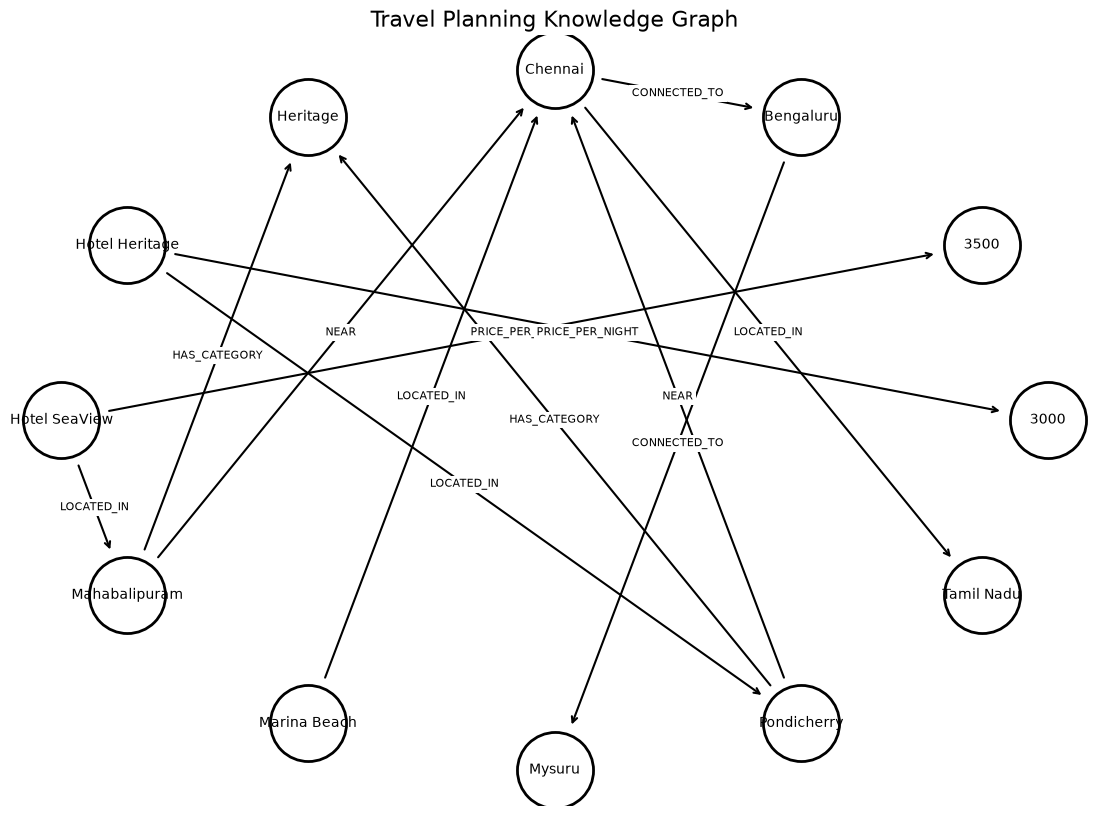

In [19]:
import matplotlib.pyplot as plt
import math

# Extract all nodes
nodes = set()

for subject, relationship, object_ in triples:
    nodes.add(subject)
    nodes.add(object_)

nodes = sorted(nodes, key=str)

# Assign positions around a circle
n = len(nodes)

positions = {}

for i, node in enumerate(nodes):

    angle = 2 * math.pi * i / n

    x = math.cos(angle)
    y = math.sin(angle)

    positions[node] = (x, y)

# Create figure
plt.figure(figsize=(14, 10))

# Draw nodes
for node, (x, y) in positions.items():

    plt.scatter(
        x,
        y,
        s=3000,
        facecolors="white",
        edgecolors="black",
        linewidths=2,
        zorder=2
    )

    plt.text(
        x,
        y,
        str(node),
        ha="center",
        va="center",
        fontsize=10,
        zorder=3
    )

# Draw edges and relationship labels
for subject, relationship, object_ in triples:

    x1, y1 = positions[subject]
    x2, y2 = positions[object_]

    plt.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.5,
            shrinkA=35,
            shrinkB=35
        ),
        zorder=1
    )

    # Relationship label
    label_x = (x1 + x2) / 2
    label_y = (y1 + y2) / 2

    plt.text(
        label_x,
        label_y,
        relationship,
        fontsize=8,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            pad=2
        ),
        zorder=4
    )

plt.title(
    "Travel Planning Knowledge Graph",
    fontsize=16
)

plt.axis("off")
plt.show()

# Step 12: Think Like a Knowledge Graph Designer

We have built a KG, but now we should think about its design.

Ask:

### What are our entities?

Examples:

- City
- Destination
- Hotel
- Attraction

### What are our relationships?

Examples:

- NEAR
- LOCATED_IN
- CONNECTED_TO
- HAS_CATEGORY

### What are our values?

Examples:

- 3500
- 3000

This is the beginning of **schema design**.

In a larger Knowledge Graph, we would explicitly define:

- entity types
- relationship types
- properties
- constraints
- meanings of relationships

This will be developed further in later notebooks.

# Notebook 2 — Summary

We started with a real-world problem:

**Travel Planning**

We then followed this path:

**Travel information**
↓
**Entities**
↓
**Relationships**
↓
**Triples**
↓
**Graph structure**
↓
**Queries**
↓
**Multi-hop traversal**
↓
**Combining facts**
↓
**Travel recommendation**

The central idea is:

> **A Knowledge Graph represents knowledge as interconnected entities and meaningful relationships, allowing us to retrieve and traverse information through those relationships.**

In the next notebook, we will make our querying much more powerful.
We will build functions that can answer different types of questions
from the graph and explore **multi-hop queries and reasoning chains**.